# MAGIC Gamma Telescope - Classification Models Comparison 

This notebook presents a full machine learning workflow for classifying high-energy gamma-ray events using the MAGIC Gamma Telescope dataset.


##  Objective

We aim to build and evaluate classification models to distinguish between:
- **Gamma (signal)** events
- **Hadron (background)** events

###  Steps:
1. Load and balance the dataset
2. Split the data into training and testing sets
3. Train and evaluate four models:
   - Decision Tree
   - Naïve Bayes
   - Random Forest (with tuning)
   - AdaBoost (with tuning)
4. Compare models using:
   - Accuracy
   - Precision
   - Recall
   - F1 Score
   - Confusion Matrix


______________________________________________________________________________
##  Step 0: Import Required Libraries

We'll import all the Python libraries we need for:
- Data handling and visualization (`pandas`, `numpy`, `matplotlib`, `seaborn`)
- Machine learning (`scikit-learn`)
- Evaluation metrics and model selection


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB


##  Step 1: Load and Prepare the Data
load the dataset and take a look at the structure.


In [17]:
df = pd.read_csv("C:/Users/DELL/Desktop/Machine Learning/ML assignment 2/MAGIC-Gamma-Classification-Models/data/magic04.data", header=None)

# Set column names
df.columns = ["fLength", "fWidth", "fSize", "fConc", "fConc1",
              "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]

# Map class labels to binary (g:1, h:0)
df["class"] = df["class"].map({"g": 1, "h": 0})

# Preview
df.head()


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


##  Step 2: Balance the Dataset
The dataset is imbalanced. We'll undersample the gamma class to match the hadron class.


In [18]:
print("Original class distribution:\n", df["class"].value_counts())

# Undersample gamma to 6688 (equal to hadron)
gamma_df = df[df["class"] == 1].sample(n=6688, random_state=42)
hadron_df = df[df["class"] == 0]
balanced_df = pd.concat([gamma_df, hadron_df]).sample(frac=1, random_state=42)

# Check new distribution
print("Balanced class distribution:\n", balanced_df["class"].value_counts())


Original class distribution:
 1    12332
0     6688
Name: class, dtype: int64
Balanced class distribution:
 0    6688
1    6688
Name: class, dtype: int64


##  Step 3: Train-Test Split
We split the balanced dataset into 70% training and 30% testing.


In [19]:
X = balanced_df.drop("class", axis=1)
y = balanced_df["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


##  Step 4: Define Evaluation Function
We'll use accuracy, precision, recall, F1 score, and confusion matrix for evaluation.


In [20]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n🧪 {name} Results:")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(name + " Confusion Matrix")
    plt.show()


###  Model 1: Decision Tree
A simple and interpretable model without parameter tuning.



🧪 Decision Tree Results:
Accuracy:  0.7854
Precision: 0.7764
Recall:    0.7925
F1 Score:  0.7844


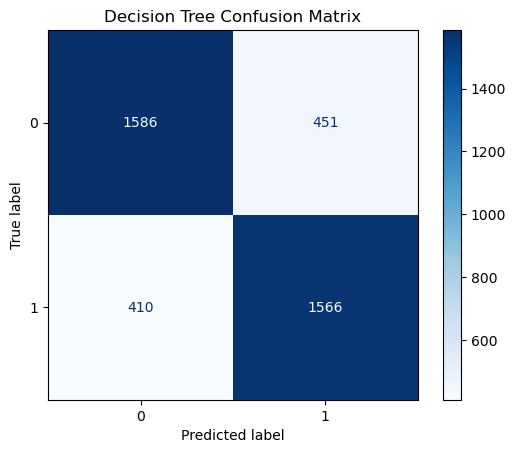

In [21]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
evaluate_model("Decision Tree", dt_model, X_test, y_test)


###  Model 2: Naïve Bayes
A fast probabilistic model suitable for basic classification.



🧪 Naïve Bayes Results:
Accuracy:  0.6422
Precision: 0.5904
Recall:    0.8922
F1 Score:  0.7106


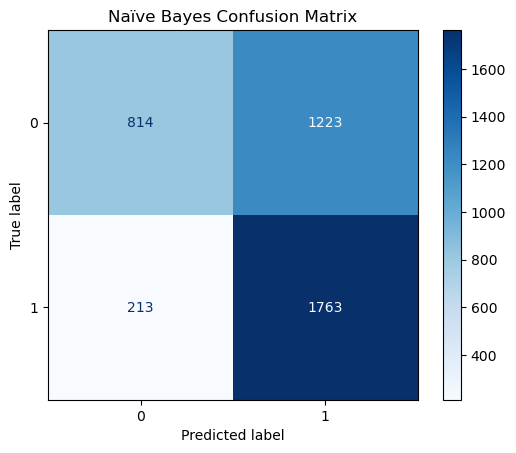

In [22]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
evaluate_model("Naïve Bayes", nb_model, X_test, y_test)


###  Model 3: Random Forest (Tuned)
An ensemble of decision trees. We'll tune the `n_estimators` parameter using GridSearchCV.



🧪 Random Forest (Best) Results:
Accuracy:  0.8507
Precision: 0.8265
Recall:    0.8821
F1 Score:  0.8534


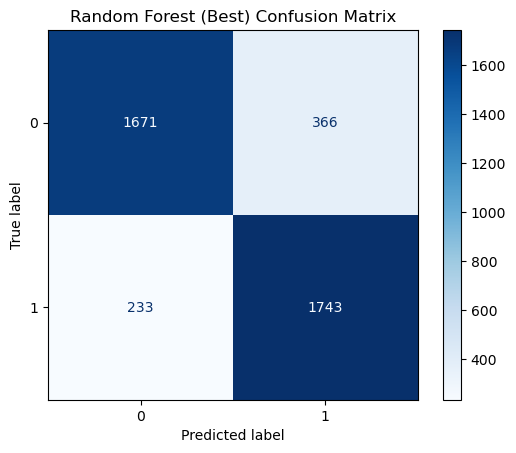

In [23]:
rf_params = {"n_estimators": [50, 100, 150]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid.fit(X_train, y_train)

evaluate_model("Random Forest (Best)", rf_grid.best_estimator_, X_test, y_test)


###  Model 4: AdaBoost (Tuned)
A boosting algorithm that improves performance by combining weak learners.



🧪 AdaBoost (Best) Results:
Accuracy:  0.8228
Precision: 0.8105
Recall:    0.8355
F1 Score:  0.8228


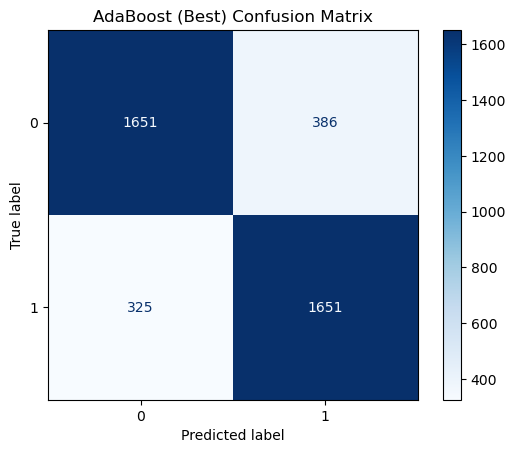

In [24]:
ada_params = {"n_estimators": [50, 100, 150]}
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), ada_params, cv=5)
ada_grid.fit(X_train, y_train)

evaluate_model("AdaBoost (Best)", ada_grid.best_estimator_, X_test, y_test)


##  Model Comparison
Compare the printed metrics above to determine the best performing classifier.


In [25]:
print(" All models have been evaluated. Check the confusion matrices and metrics to compare performance.")


 All models have been evaluated. Check the confusion matrices and metrics to compare performance.


##  Save Evaluation Results to CSV


In [31]:
results_dict = {
    "Decision Tree": dt_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_grid.best_estimator_,
    "AdaBoost": ada_grid.best_estimator_
}

metrics_list = []
for name, model in results_dict.items():
    y_pred = model.predict(X_test)
    metrics_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(metrics_list)
results_df.to_csv("C:/Users/DELL/Desktop/Machine Learning/ML assignment 2/MAGIC-Gamma-Classification-Models/reports/metrics.csv", index=False)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.785447,0.776401,0.792510,0.784373
1,Naive Bayes,0.642163,0.590422,0.892206,0.710601
2,Random Forest,0.850735,0.826458,0.882085,0.853366
3,AdaBoost,0.822826,0.810506,0.835526,0.822826


##  Visual Comparison of Models
Let's visualize the Accuracy, Precision, Recall, and F1 Score for better comparison.


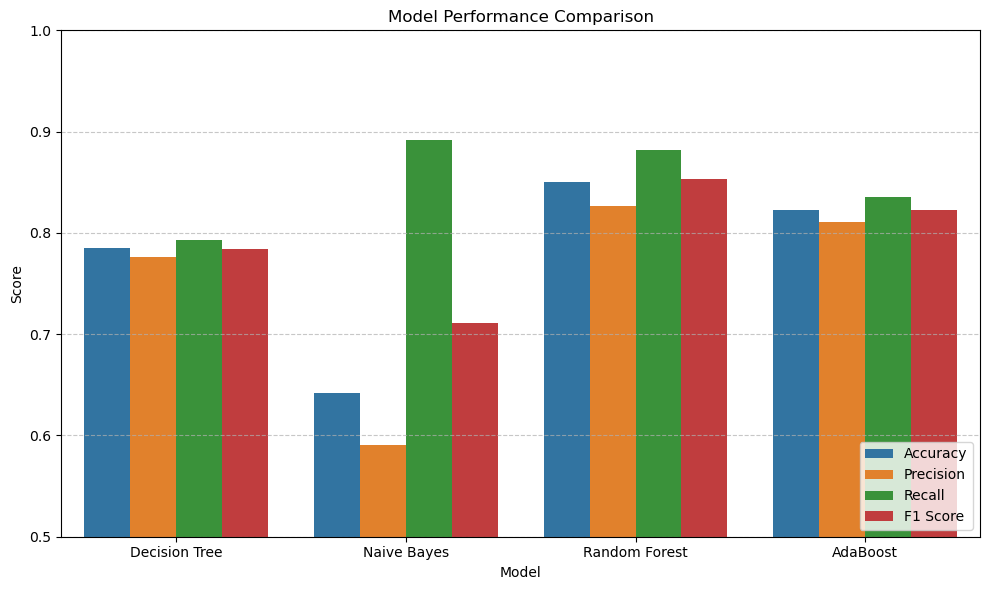

In [32]:
# Melt the results dataframe for seaborn plotting
metrics_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.ylim(0.5, 1.0)
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(loc="lower right")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


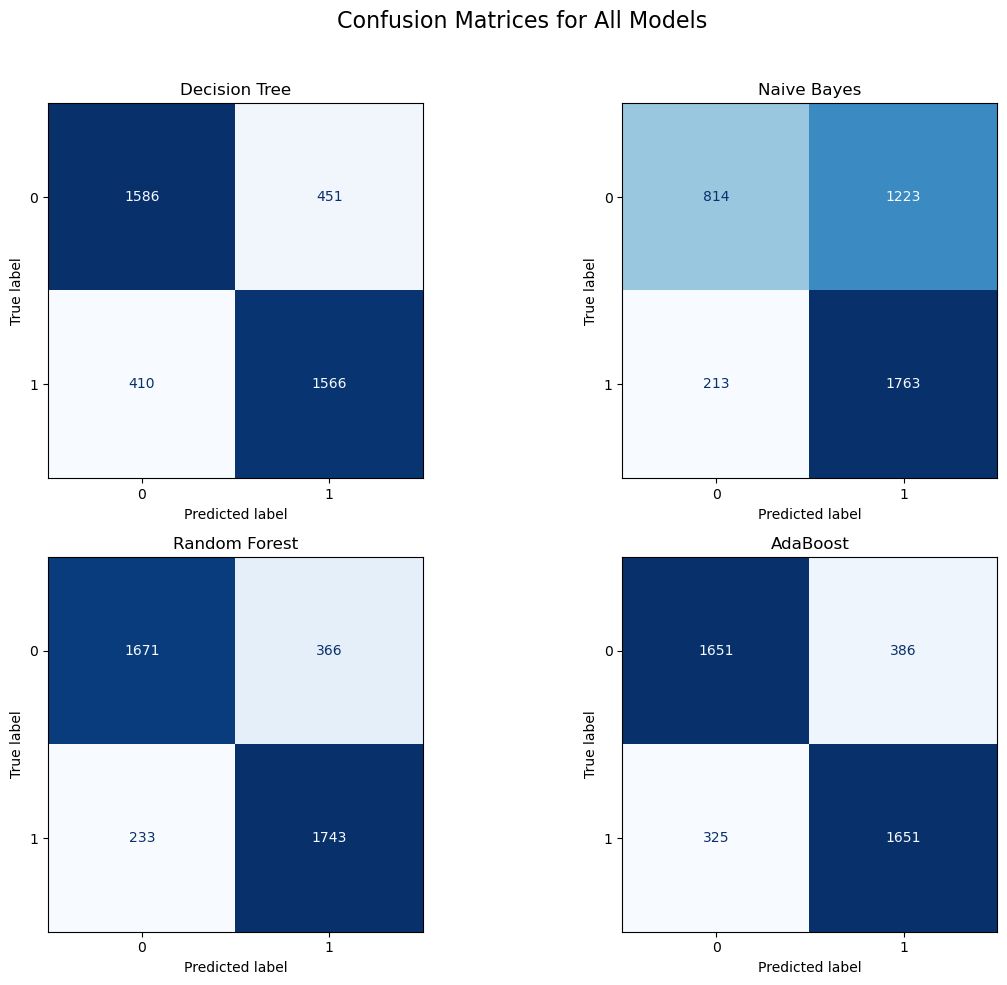

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices for All Models", fontsize=16)

models = {
    "Decision Tree": dt_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_grid.best_estimator_,
    "AdaBoost": ada_grid.best_estimator_
}

axes = axes.flatten()
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##  Conclusion

- All models performed reasonably well after balancing the dataset.
- Ensemble models (Random Forest, AdaBoost) achieved better results with tuning.
- Naïve Bayes was the fastest but less accurate.
- Decision Tree was simple and interpretable.

> This notebook demonstrates a full classification pipeline with best practices for model evaluation.
